<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Final
#### Milena Waichman Scigliano


En esta primera parte de preprocesamiento de la señal, se realizaron las siguientes acciones:
- Creacion de la señal: usando la libreria wfdb para acceder el dataset elegido para el trabajo. A partir de los registros disponibles se generó la señal temporal, definiendo parámetros como la frecuencia de muestreo (fs), el vector temporal (t) y el canal de análisis. Dado que el registro cuenta con tres canales correspondientes a distintas ubicaciones de medición abdominal, se seleccionó el primer canal por presentar mejor relación señal-ruido y mayor estabilidad en el registro respecto a los otros canales.
- Filtrado: una vez obtenida la señal se continuo con el filtrado. Utilizando los datos brindados por los papers de la bibliografia se eligieron los parametros para el armado de la plantilla. La mayor parte de la información relevante se encuentra en el rango de 0.3–3 Hz, por lo que se diseñó una plantilla que respeta dicha banda. Se implemento un filtro pasabanda de tipo Butterworth, aplicado de forma bidireccional. La respuesta en magnitud fue verificada utilizando la plantilla trabajada en clase, comprobando que las frecuencias fuera de banda se atenúan aproximadamente 40 dB, lo cual resulta adecuado para este tipo de análisis.
- Normalizacion: la señal fue normalizada utilizando la media y el desvio estandar para facilitar la comparacion entre distintos registros y reducir la influencia de diferencias de amplitud entre señales.
- Ventaneo: la señal fue segmentada en ventanas de 120 segundos con un solapamiento del 50%, siguiendo las recomendaciones encontradas en la bibliografía. Este procedimiento permite analizar la señal de forma estacionaria y estudiar las características extraídas.

Hasta este punto se completó la etapa de preprocesamiento.
Los siguientes pasos consistirán en la extracción de características relevantes en el dominio temporal y espectral para posteriormente realizar la comparación entre señales.




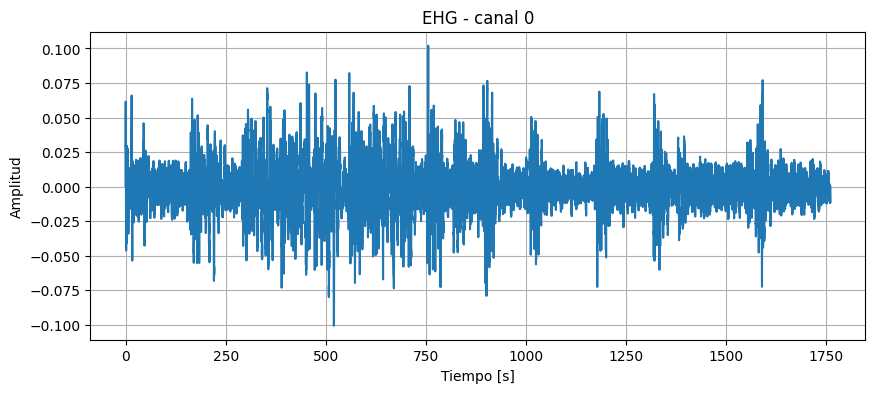

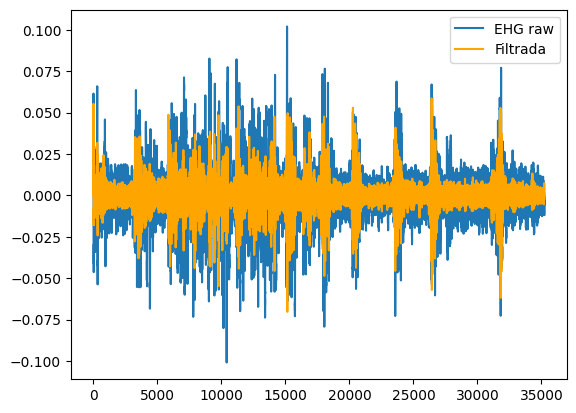

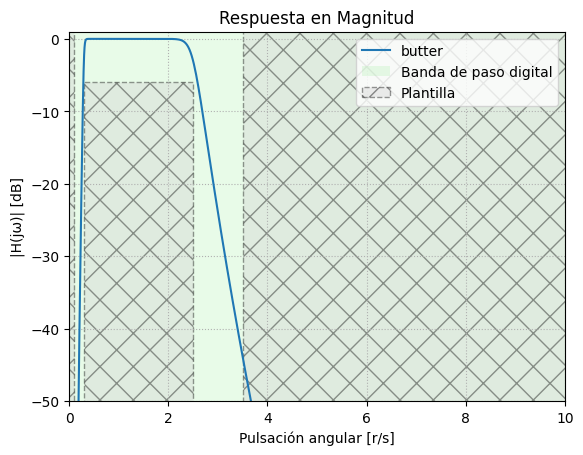

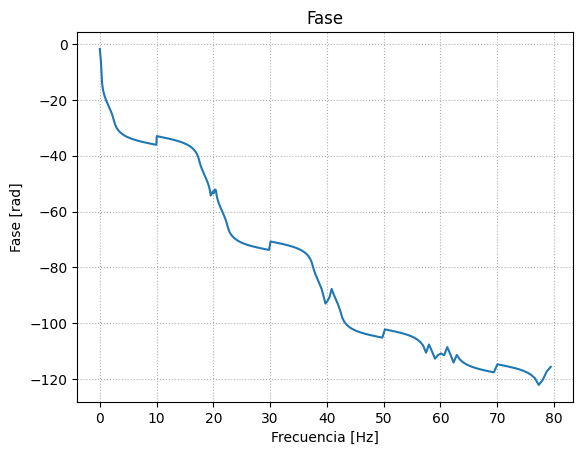

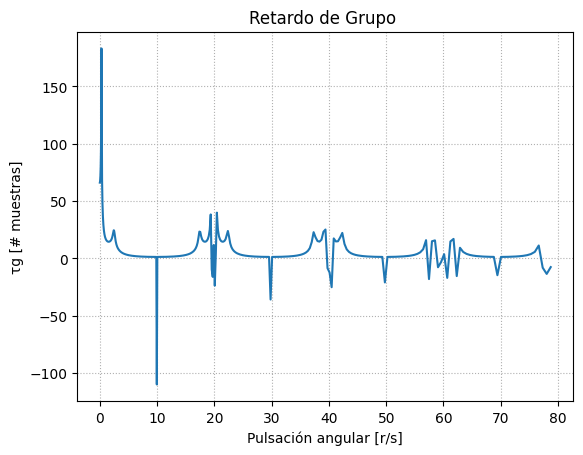

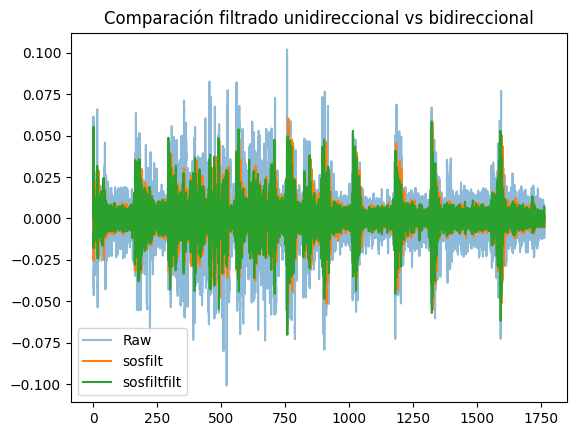

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Feb 10 10:02:05 2026

@author: milenawaichnan
"""

import numpy as np
import matplotlib.pyplot as plt
import wfdb as wfdb
from scipy import signal
import scipy.io as sio

from pytc2.sistemas_lineales import plot_plantilla


## --- CREACION DE LA SENAL ----- ##
archivo = wfdb.rdrecord('datos/later_induced/icehg606')

senal = archivo.p_signal      # matriz (N muestras × canales)
fs = archivo.fs                # frecuencia de muestreo = 20 --> nyquist = 10
channels = archivo.sig_name    # nombres de los canales


ehg = senal[:,1]
t = np.arange(len(ehg)) / fs

# SENAL CRUDA
plt.figure(figsize=(10,4))
plt.plot(t, ehg)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('EHG - canal 0')
plt.grid()
plt.show()

# %%
## --- FILTRADO --- ##
wp = (0.3, 2.5) #freq de corte/paso (Hz)
ws = (0.1, 3.5) #freq de stop/detenida (Hz)

#si alpha_p es =3 -> max atenuacion, butter

alpha_p = 3 #atenuacion de corte/paso, alfa_max, perdida en banda de paso 
alpha_s = 40 #atenuacion de stop/detenida, alfa_min, minima atenuacion requerida en banda de paso 


#Aprox de modulo
f_aprox = 'butter'
mi_sos_butter = signal.iirdesign(wp = wp, ws = ws, gpass = alpha_p, gstop = alpha_s, analog = False, ftype = f_aprox, output ='sos', fs=fs)
w, h= signal.freqz_sos(mi_sos_butter, worN = np.logspace(-2, 1.9, 1000), fs = fs) #calcula rta en frq del filtro, devuelve w y vector de salida (h es numero complejo)

ehg_filt = signal.sosfiltfilt(mi_sos_butter, ehg)

fase = np.unwrap(np.angle(h)) #unwrap hace grafico continuo

w_rad = w / (fs / 2) * np.pi
gd = -np.diff(fase) / np.diff(w_rad) #retardo de grupo [rad/rad]


#RAW VS FILTRADA
plt.figure()
plt.plot(ehg, label = 'EHG raw')
plt.plot(ehg_filt, label = 'Filtrada', color = 'orange')
plt.legend()

#Rta en magnitud
plt.figure()
plt.plot(w, 20*np.log10(np.maximum(abs(h), 1e-10)), label = f_aprox)
plot_plantilla(filter_type = 'bandpass' , fpass = wp, ripple = alpha_p*2 , fstop = ws, attenuation = alpha_s*2, fs = fs)
plt.title('Respuesta en Magnitud')
plt.xlabel('Pulsación angular [r/s]')
plt.ylabel('|H(jω)| [dB]')
plt.xlim([0, 10])
plt.ylim([-50, 1])
plt.grid(True, which='both', ls=':')
plt.legend()

#Fase
plt.figure()
plt.plot()
plt.plot(w, fase, label = f_aprox)
plt.title('Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.grid(True, which='both', ls=':')

# Retardo de grupo
plt.figure()
plt.plot()
plt.plot(w[:-1], gd, label = f_aprox)
plt.title('Retardo de Grupo ')
plt.xlabel('Pulsación angular [r/s]')
plt.ylabel('τg [# muestras]')
plt.grid(True, which='both', ls=':')

#Filtrado unidireccional vs bidireccional
ehg_lf = signal.sosfilt(mi_sos_butter, ehg)

plt.figure()
plt.plot(t, ehg, label='Raw', alpha=0.5)
plt.plot(t, ehg_lf, label='sosfilt')
plt.plot(t, ehg_filt, label='sosfiltfilt')
plt.legend()
plt.title('Comparación filtrado unidireccional vs bidireccional')


# --- NORMALIZACION ---

media = np.mean(ehg_filt)
desvio = np.std(ehg_filt)

ehg_norm = (ehg_filt - media) / desvio


# --- RECORTE EN VENTANAS ---
window_length = 120 # segundos
overlap = 0.5

L = int(window_length * fs)
step = int(L * (1 - overlap))

ventanas = []   #quedan 28 ventanas
for start in range(0, len(ehg_filt) - L + 1, step):
    ventanas.append(ehg_filt[start:start+L])

#chequeo de ventanas!!
# print("L:", L)
# print("Step:", step)
# print("Cantidad de ventanas:", len(ventanas))

# n_teorico = (len(ehg_filt) - L) // step + 1
# print("Ventanas teóricas:", n_teorico)
